#**Data Understanding**


Tahap Data Understanding merupakan langkah awal dalam metodologi CRISP-DM setelah penyelesaian tahap Business Understanding. Pada fase ini, kegiatan difokuskan pada proses memahami data yang akan dianalisis sebelum memasuki tahap persiapan data maupun pembangunan model.

Tujuan utama dari tahap ini adalah memperoleh pemahaman yang komprehensif terhadap struktur, karakteristik, dan kondisi data. Dengan pemahaman tersebut, peneliti atau analis dapat menentukan strategi yang tepat pada tahap selanjutnya, yaitu Data Preparation, sehingga proses analisis dapat berjalan lebih sistematis dan meminimalkan potensi kesalahan dalam pengembangan model.


#**1. Sumber Data**

Dataset yang digunakan dalam penelitian ini adalah Iris Flower Dataset yang diperoleh melalui platform Kaggle. Dataset tersebut memuat data pengukuran morfologi bunga iris yang terdiri atas tiga spesies, yaitu Iris-setosa, Iris-versicolor, dan Iris-virginica. Data ini sering digunakan sebagai studi kasus dalam analisis klasifikasi karena memiliki struktur yang sederhana namun representatif untuk pengenalan pola.

#**2. Eksplorasi Dataset**

Pada tahap eksplorasi data, bahasa pemrograman Python digunakan untuk mempermudah proses identifikasi dan analisis dataset. Python membantu dalam menampilkan struktur data, memahami tipe variabel, serta melakukan pemeriksaan awal terhadap isi dataset.

Beberapa langkah awal yang dilakukan meliputi:

- Persiapan library yang dibutuhkan untuk analisis data.

- Pengaturan akses atau perizinan terhadap penyimpanan (misalnya Google Drive) apabila dataset tersimpan secara daring.

##2.1 connect pyhton ke database

###2.1.1 Connect MySQL ke Python

In [ ]:
pip install mysql-connector-python

Sebelum menghubungkan MySQL dengan Python, terlebih dahulu perlu menyiapkan environment yang dibutuhkan, salah satunya dengan menginstal library yang disebutkan di atas.

In [ ]:
import mysql.connector
db = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="iris"
)
print("Berhasil terhubung ke MySQL!")

cursor = db.cursor()

cursor.execute("SELECT * FROM iris")

hasil = cursor.fetchall()

for data in hasil:
    print(data)

db.close()

Berikutnya, masukkan kode ini ke dalam file Python kita. Pastikan bahwa pada database MySQL sudah terdapat database bernama iris, yang disesuaikan dengan nama file CSV yang digunakan sebelumnya.

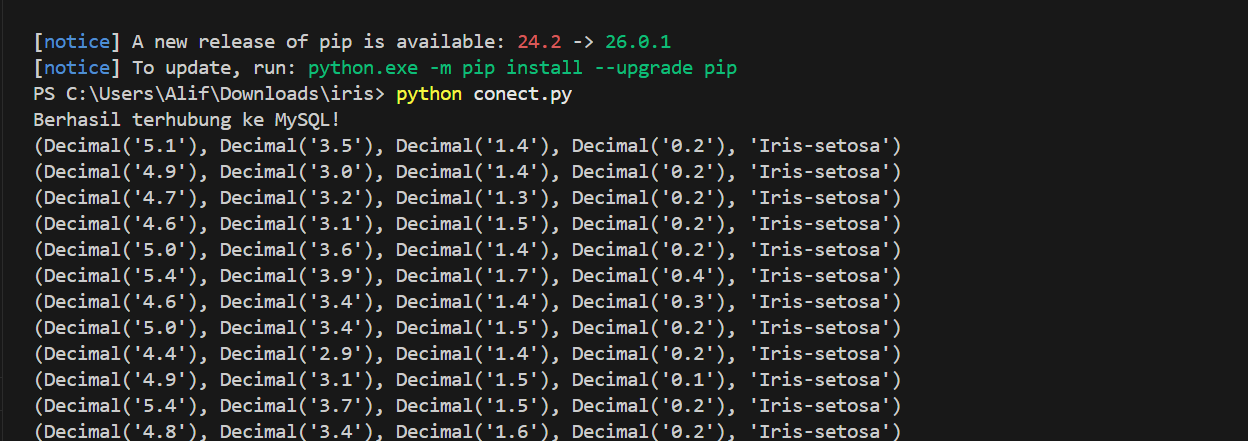

Hasil yang ditampilkan ketika program dijalankan dan koneksi antara MySQL dan Python berhasil terhubung.

###2.1.2 Connect PostgreSQL ke Python

In [ ]:
pip install psycopg2

Sama seperti pada MySQL, kita juga perlu menyiapkan environment untuk PostgreSQL dengan cara menginstal library psycopg2 seperti yang disebutkan di atas.

In [ ]:
import psycopg2
conn = psycopg2.connect(
    host="localhost",
    database="iris",
    user="postgres",
    password="123",
    port="5432"
)
print("Berhasil connect ke PostgreSQL")
cursor = conn.cursor()

cursor.execute("SELECT * FROM iris")

rows = cursor.fetchall()
for row in rows:
    print(row)

cursor.close()
conn.close()

Masukkan contoh kode di atas ke dalam program, lalu sesuaikan nama database dan nama tabel dengan yang digunakan pada sistem yang dimiliki.

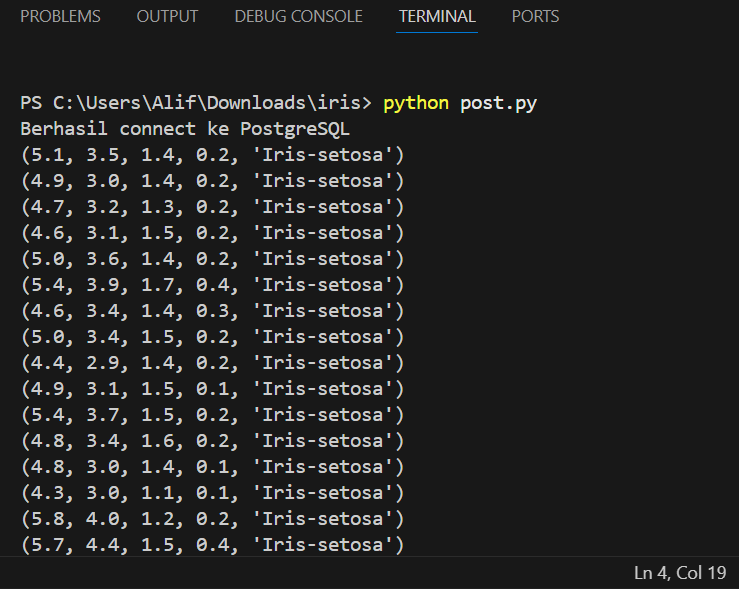

Berikut merupakan hasil yang ditampilkan ketika koneksi ke database berhasil dilakukan.

###2.1.3 Connect PostgreSQL ke Orange

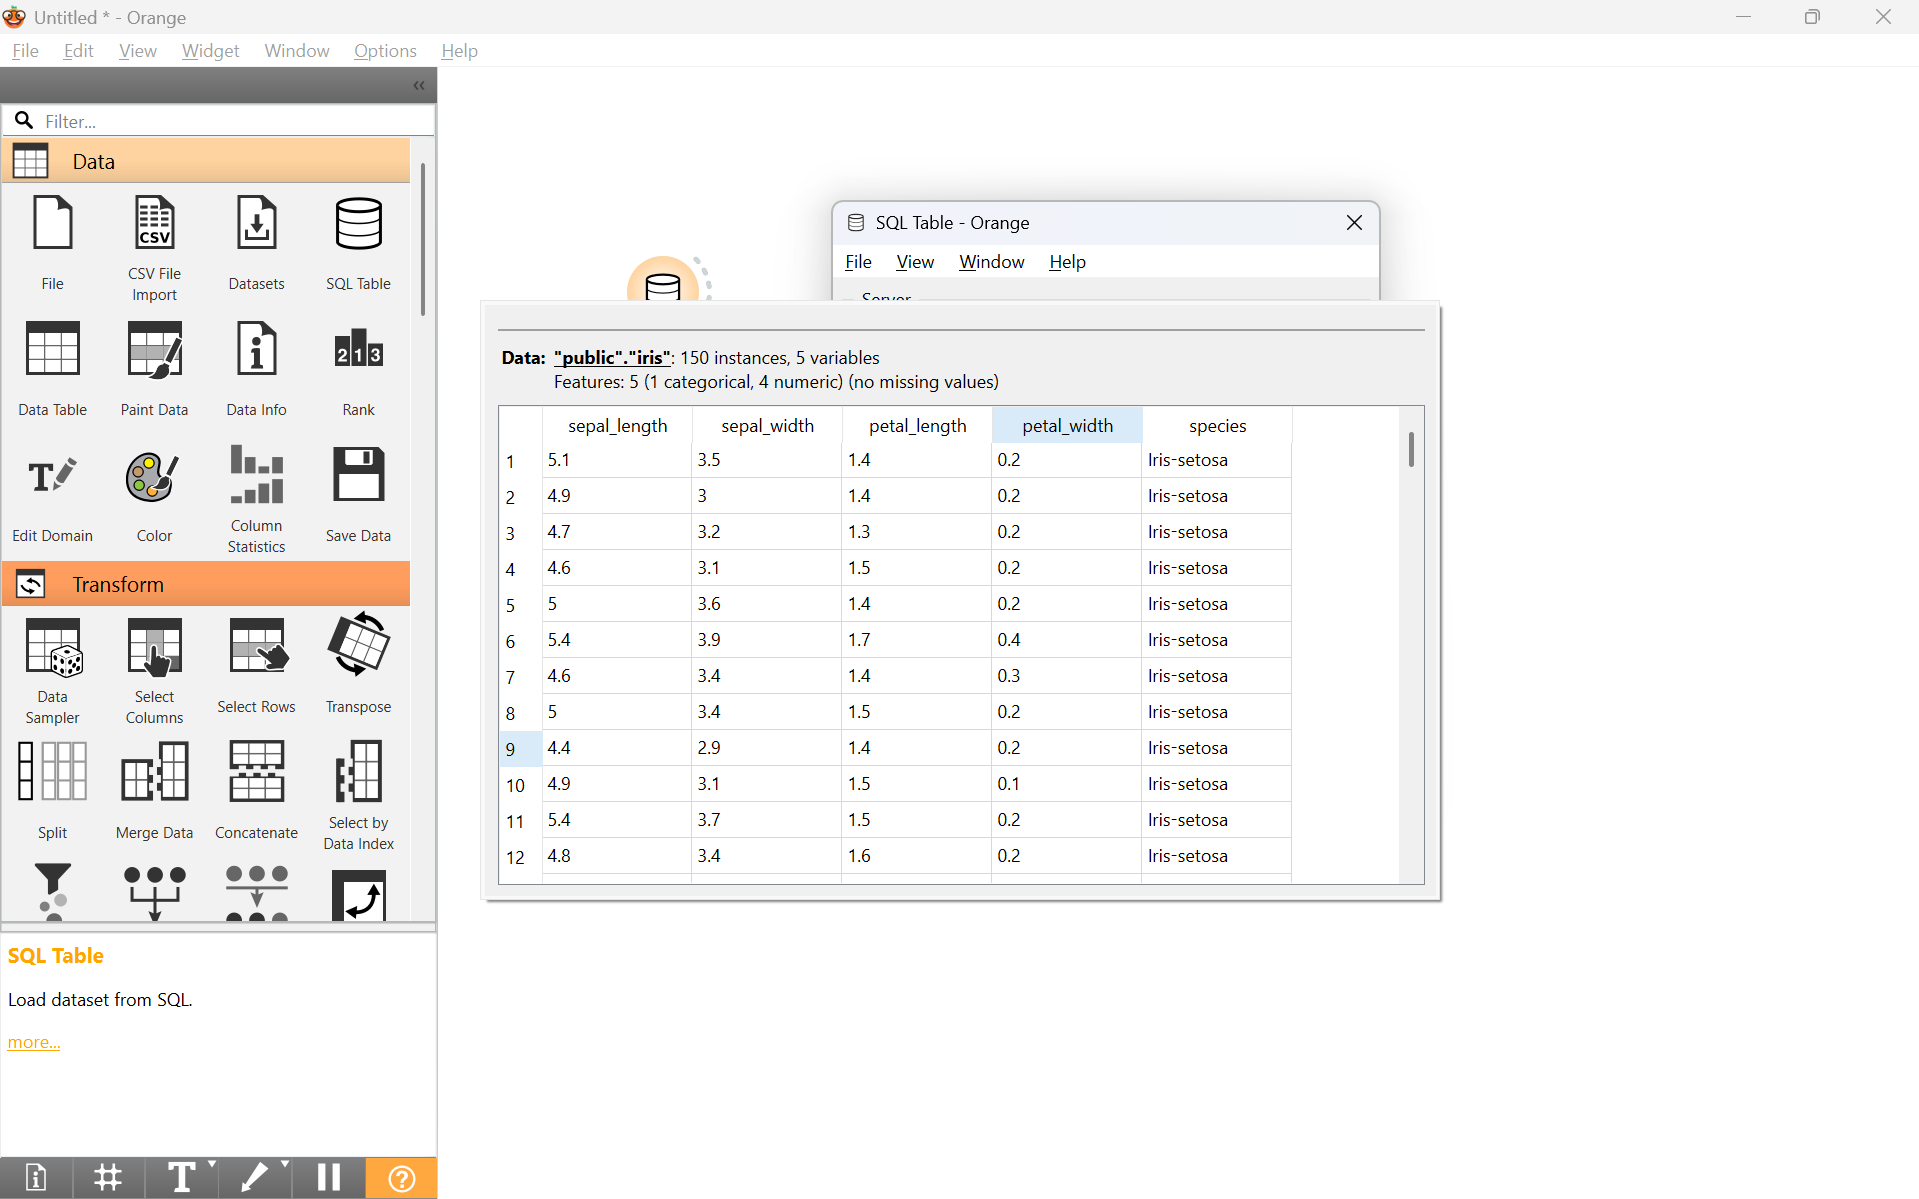

penjelasan

##2.2 Persiapan library dan perizinan drive

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt

drive.mount('/content/drive')

Proses ini berfungsi untuk menyiapkan lingkungan kerja analisis data di Google Colab agar dapat terhubung dengan penyimpanan eksternal dan mendukung pengolahan serta visualisasi data. Integrasi dengan Google Drive memungkinkan akses langsung ke file atau dataset yang tersimpan secara online sehingga tidak perlu mengunggah ulang setiap sesi. Library Pandas digunakan sebagai alat utama untuk membaca, mengelola, dan memanipulasi data dalam bentuk tabel, sedangkan Matplotlib dimanfaatkan untuk membuat berbagai visualisasi seperti grafik dan plot guna membantu proses analisis. Dengan konfigurasi ini, aktivitas pengolahan data menjadi lebih terstruktur karena data dapat diambil dari Drive, diolah menggunakan Pandas, lalu divisualisasikan untuk memperoleh insight yang lebih jelas.

## 2.3 Menentukan path drive

In [ ]:
path = "/content/drive/MyDrive/IRIS.csv"
df = pd.read_csv(path)

Dalam kasus ini file IRIS.csv berada dalam folder tugas, maka path kita arahkan menuju folder tugas, lalu gunakan library pandas untuk membaca isi file nya



## 2.4 Struktur Dataset

In [ ]:
df.head()

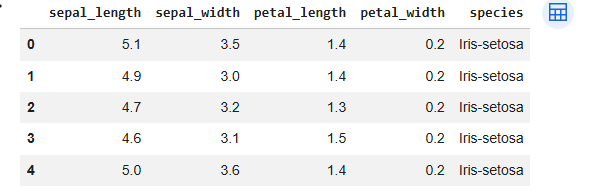

code diatas digunakan untuk menampilkan 5 data teratas yang ada di dalam file IRIS.csv.

Setiap data memiliki 4 atribut numerik yang merepresentasikan ukuran bagian bunga dalam satuan centimeter (cm), yaitu:

1. Sepal Length – Panjang kelopak bunga

2. Sepal Width – Lebar kelopak bunga

3. Petal Length – Panjang mahkota bunga

4. Petal Width – Lebar mahkota bunga Selain itu, terdapat satu atribut kategorikal yaitu:

5. Species – Label kelas yang menunjukkan jenis bunga iris yang terdiri dari tiga kategori:
    - Setosa
    - Versicolor
    - Virginica

## 2.5 Statistik Deskriptif Awal

In [ ]:
df.describe()

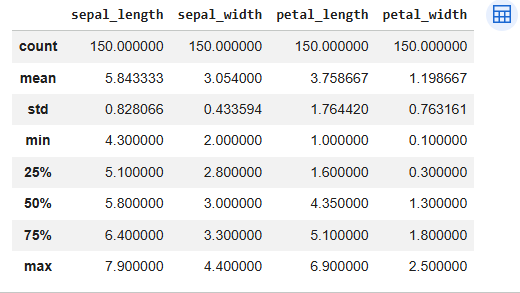

Berdasarkan hasil statistik deskriptif, dataset Iris terdiri dari 150 data pada setiap atribut. Nilai rata-rata menunjukkan bahwa ukuran sepal dan petal berada pada rentang yang wajar, dengan panjang sepal rata-rata sekitar 5.84 cm dan panjang petal sekitar 3.76 cm. Variasi data terbesar terdapat pada atribut petal length, sedangkan variasi terkecil terdapat pada sepal width, yang menunjukkan bahwa ukuran petal lebih beragam dibandingkan ukuran sepal. Rentang nilai minimum hingga maksimum pada setiap atribut masih berada dalam batas yang normal dan tidak menunjukkan adanya nilai ekstrem yang mencurigakan.

Standar deviasi tertinggi terdapat pada atribut petal length sebesar 1.76, yang menunjukkan bahwa variasi panjang petal lebih besar dibandingkan atribut lainnya. Nilai minimum dan maksimum menunjukkan rentang data yang masih dalam batas wajar, yaitu sepal length antara 4.3 hingga 7.9 cm dan petal width antara 0.1 hingga 2.5 cm. Selain itu, nilai kuartil (25%, 50%, dan 75%) menunjukkan distribusi data yang relatif stabil tanpa adanya penyimpangan ekstrem yang signifikan.

## 2.6 Pengecekan Data Duplikat

In [ ]:
df.duplicated().sum()

Screenshot 2026-02-25 093912.png

Code di atas merupakan code untuk pengecekan data duplikat,setelah dilakukan pengecekan, terdapat data duplikat yaitu ada 3 data duplikat

##2.7 Pengecekan Data Null

In [ ]:
df.isnull().sum()

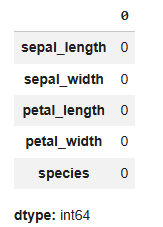

Hasil diatas menunjukan tidak adanya data Null, ditambah pada penfecekan deskriptif awal menunjukan bahwa seluruh data memiliki jumlah yang sama, artinya tidak ada data null di setiap atribut nya.

# **3. Analisa korelasi**

Analisis korelasi digunakan untuk mengetahui hubungan antar variabel numerik dalam dataset. Korelasi menunjukkan seberapa kuat hubungan antara dua variabel serta arah hubungannya (positif atau negatif).

Nilai korelasi berada pada rentang:
- -1 → hubungan negatif sempurna
- 0 → tidak ada hubungan

- +1 → hubungan positif sempurna

Pada dataset Iris, analisis korelasi dilakukan pada empat atribut numerik, yaitu:

- sepal_length

- sepal_width

- petal_length

- petal_width

In [ ]:
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)

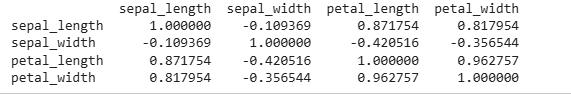

Berdasarkan hasil perhitungan korelasi Pearson antar fitur numerik, diperoleh matriks korelasi seperti diatas

Interpretasi
- petal_length dan petal_width (0.962757) memiliki korelasi positif yang sangat kuat. Hal ini menunjukkan bahwa semakin panjang petal, maka semakin lebar petal.

- sepal_length dan petal_length (0.871754) menunjukkan hubungan positif yang kuat.

- sepal_length dan petal_width (0.817954) juga memiliki korelasi positif yang kuat.

- sepal_width memiliki korelasi yang relatif lemah hingga sedang terhadap fitur lainnya, bahkan bernilai negatif.

# **4. Verifikasi Data**

Berdasarkan hasil eksplorasi sebelumnya, diketahui bahwa dataset terdiri dari 150 data dengan jumlah yang konsisten pada setiap atribut numerik. Hasil pengecekan menggunakan df.isnull().sum() menunjukkan bahwa seluruh kolom memiliki nilai 0 pada bagian null, yang berarti tidak terdapat data kosong (missing value) pada dataset.

Selanjutnya, dilakukan pengecekan data duplikat menggunakan df.duplicated().sum(), dan diperoleh hasil sebanyak 3 data duplikat. Hal ini menunjukkan bahwa terdapat beberapa baris data yang identik dan berpotensi mempengaruhi hasil analisis jika tidak ditangani.

# **5. Visualisasi Data**

## 5.1 Visualisasi data menggunakan Pyton

### **Distribusi Jumlah Data per Specie**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='species'
)

plt.title("Distribusi Jumlah Data per Species")
plt.xlabel("Species")
plt.ylabel("Jumlah Data")

plt.show()

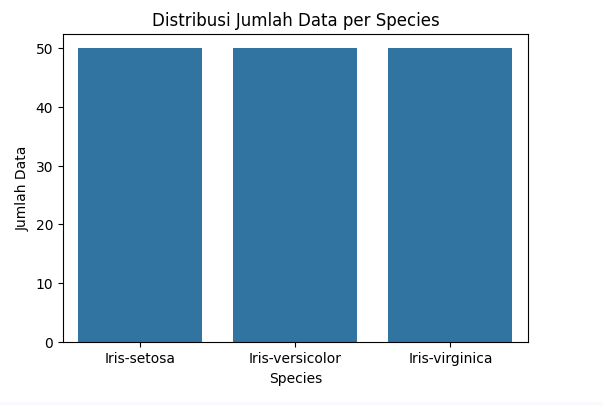

Grafik bar digunakan untuk melihat jumlah data pada setiap species. Berdasarkan grafik, diketahui bahwa setiap species yaitu Iris-setosa, Iris-versicolor, dan Iris-virginica masing-masing memiliki 50 data. Hal ini menunjukkan bahwa dataset dalam kondisi seimbang (balanced dataset), sehingga tidak terdapat ketimpangan jumlah data antar kelas. Kondisi ini sangat baik untuk proses modeling karena dapat membantu menghasilkan model klasifikasi yang lebih akurat dan tidak bias terhadap kelas tertentu.

### **Distribusi Data Fitur Numerik pada Dataset Iris**

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df.hist()

plt.suptitle("Distribusi Data Fitur Numerik pada Dataset Iris")
plt.show()

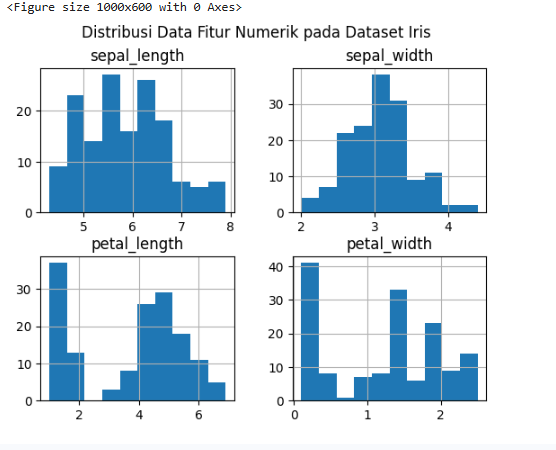

Berdasarkan histogram, dapat disimpulkan bahwa seluruh fitur numerik memiliki distribusi yang bervariasi dan tidak terdapat anomali yang ekstrem. Fitur petal_length dan petal_width menunjukkan pola distribusi yang lebih jelas dalam membedakan kelompok data, sehingga kedua fitur ini sangat berpotensi menjadi fitur penting dalam proses klasifikasi pada tahap modeling. Visualisasi ini membantu dalam memahami karakteristik dan penyebaran data pada tahap Data Understanding dalam metodologi CRISP-DM.

### **Visualisasi scatter plot sepal**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x='sepal_length',
    y='sepal_width',
    hue='species'
)

plt.title("Scatter Plot Sepal Length vs Sepal Width")
plt.show()

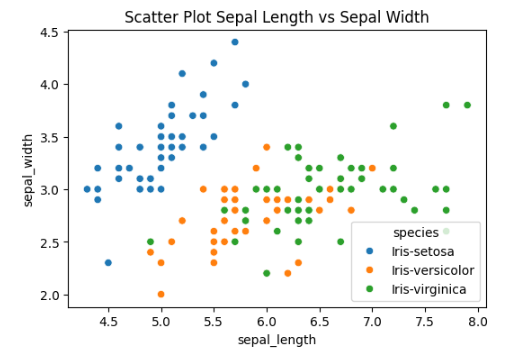

Kode tersebut digunakan untuk membuat visualisasi scatter plot yang menampilkan hubungan antara sepal_length pada sumbu X dan sepal_width pada sumbu Y dari dataset iris. Grafik dibuat dengan ukuran 6x4 agar terlihat lebih proporsional, kemudian fungsi sns.scatterplot() digunakan untuk menampilkan titik-titik data dengan pewarnaan berdasarkan kategori species. Pemberian warna ini bertujuan untuk mempermudah dalam melihat pola penyebaran dan perbedaan antar jenis bunga. Selanjutnya, judul grafik ditambahkan agar visualisasi lebih informatif, dan perintah plt.show() digunakan untuk menampilkan hasil plot. Visualisasi ini membantu menunjukkan bahwa hubungan antara sepal_length dan sepal_width cenderung menyebar dan tidak membentuk pola linear yang kuat, sehingga fitur sepal kurang efektif dalam membedakan species dibandingkan fitur petal.

### **Visualisasi scatter plot Petal**

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species'
)

plt.title("Scatter Plot Petal Length vs Petal Width")
plt.show()

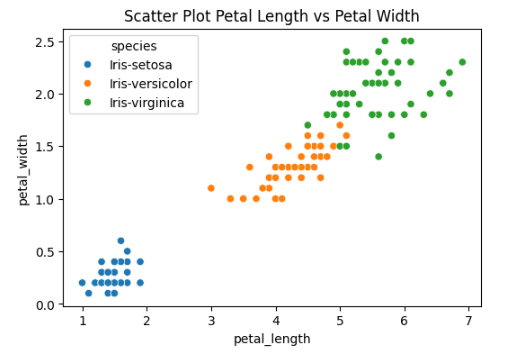

Kode tersebut digunakan untuk membuat visualisasi scatter plot yang menampilkan hubungan antara petal_length sebagai sumbu X dan petal_width sebagai sumbu Y pada dataset iris. Grafik dibuat dengan ukuran 6x4 agar tampil lebih proporsional, kemudian setiap titik data diberi warna berbeda berdasarkan kategori species sehingga pola pengelompokan antar jenis bunga dapat terlihat dengan jelas. Selanjutnya, judul grafik ditambahkan untuk memperjelas informasi yang ditampilkan, dan perintah plt.show() digunakan untuk menampilkan hasil visualisasi. Scatter plot ini membantu menunjukkan adanya hubungan positif antara panjang dan lebar petal serta memperlihatkan bahwa fitur petal mampu membedakan species dengan cukup baik.

### **Analisis Penyebaran Data dan Deteksi Outlier Menggunakan Boxplot**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(data=df[['sepal_length','sepal_width','petal_length','petal_width']])

plt.title("Analisis Penyebaran Data dan Deteksi Outlier Menggunakan Boxplot")
plt.show()

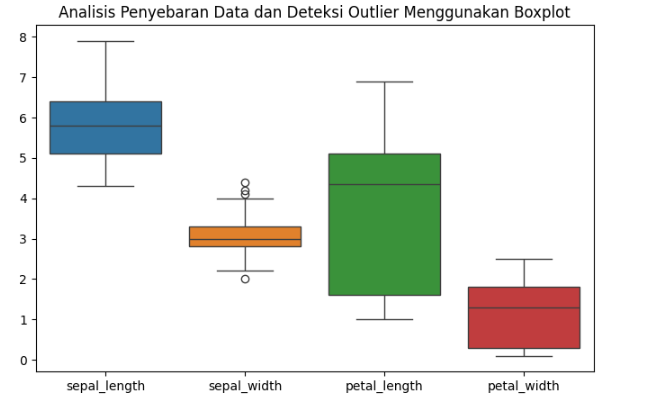

Pada setiap boxplot:
- Garis yang berada di tengah kotak menunjukkan median atau nilai tengah data.

- Batas bawah dan batas atas kotak merepresentasikan Kuartil 1 (25%) dan Kuartil 3 (75%).

- Garis yang memanjang keluar dari kotak (whisker) menggambarkan rentang nilai minimum hingga maksimum.

Berdasarkan visualisasi boxplot, terlihat bahwa masing-masing fitur memiliki tingkat penyebaran data yang berbeda. Fitur sepal_width memperlihatkan adanya beberapa nilai outlier, sedangkan fitur lain cenderung memiliki distribusi yang lebih stabil tanpa outlier yang mencolok. Selain itu, petal_length dan petal_width menunjukkan variasi data yang lebih besar, sehingga keduanya berpotensi menjadi fitur penting dalam proses pemodelan untuk membedakan antar species.


## 5.2 Visualisasi data menggunakan Orange

### **Visualisasi scatter plot sepal dan petal**

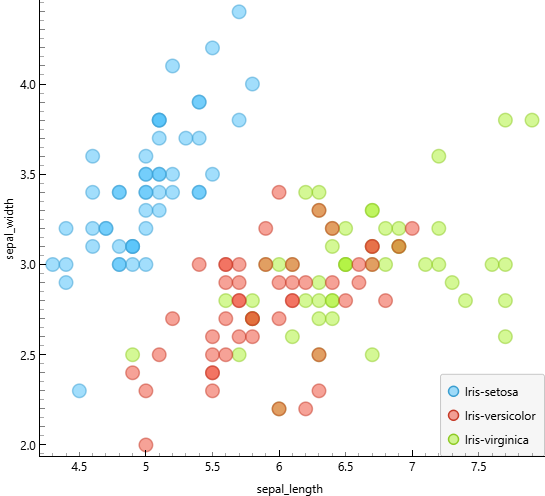

Visualisasi scatter plot tersebut memperlihatkan hubungan antara sepal_length pada sumbu X dan sepal_width pada sumbu Y melalui sebaran titik-titik data. Dari pola yang terbentuk, distribusi data terlihat cukup menyebar dan tidak membentuk garis kecenderungan linear yang kuat. Titik-titik pada grafik cenderung tersebar secara acak dengan beberapa area yang saling tumpang tindih, sehingga sulit menemukan batas pemisah yang jelas antar kelompok. Hal ini menunjukkan bahwa tingkat korelasi antara kedua variabel sepal relatif rendah. Dibandingkan dengan fitur petal yang biasanya memperlihatkan pola pemisahan yang lebih tegas, fitur sepal kurang mampu memberikan kontribusi signifikan dalam proses klasifikasi atau pembedaan species iris. Dengan demikian, dalam analisis data iris, fitur petal umumnya dianggap lebih informatif dan efektif untuk membangun model yang mampu membedakan spesies secara lebih akurat.

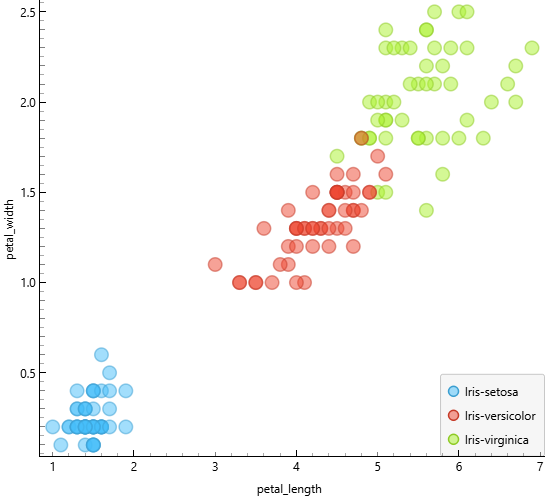

Visualisasi scatter plot berikutnya menampilkan hubungan antara petal_length pada sumbu X dan petal_width pada sumbu Y melalui sebaran titik data. Pola yang terbentuk terlihat cenderung meningkat secara linear, yang menandakan bahwa pertambahan panjang petal diikuti dengan peningkatan lebar petal. Selain itu, distribusi titik memperlihatkan pengelompokan yang lebih jelas dibandingkan fitur sepal, sehingga batas antar kelompok species dapat diamati dengan lebih mudah. Pola ini menunjukkan adanya hubungan yang kuat antara kedua variabel petal serta memperlihatkan kemampuan fitur tersebut dalam membedakan species secara lebih efektif. Temuan ini juga sejalan dengan hasil analisis korelasi yang menunjukkan bahwa petal_length dan petal_width memiliki tingkat korelasi yang tinggi, sehingga keduanya sering dianggap sebagai fitur yang paling informatif dalam proses analisis maupun klasifikasi data iris.

### Analisis Penyebaran Data dan Deteksi Outlier Menggunakan Boxplot

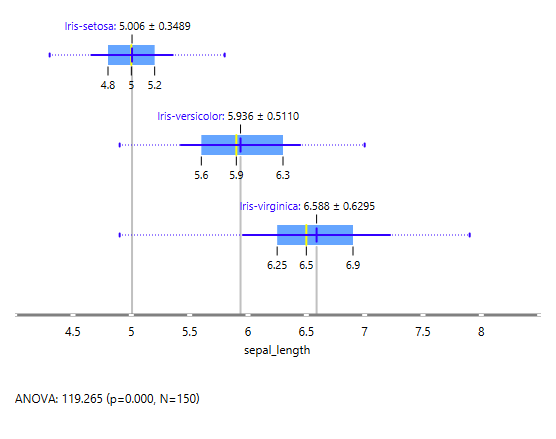

Pada setiap kotak:

Garis di tengah kotak → Median (nilai tengah)

Bagian bawah & atas kotak → Kuartil 1 (25%) dan Kuartil 3 (75%)

Garis memanjang (whisker) → Rentang minimum dan maksimum

Berdasarkan boxplot, dapat disimpulkan bahwa setiap fitur memiliki penyebaran data yang berbeda. Fitur sepal_width menunjukkan adanya beberapa outlier, sedangkan fitur lainnya memiliki distribusi yang relatif normal tanpa outlier yang signifikan. Fitur petal_length dan petal_width memiliki variasi data yang cukup besar, sehingga berpotensi menjadi fitur penting dalam membedakan species pada tahap modeling.

### **Statistik jumlah keseluruhan data**

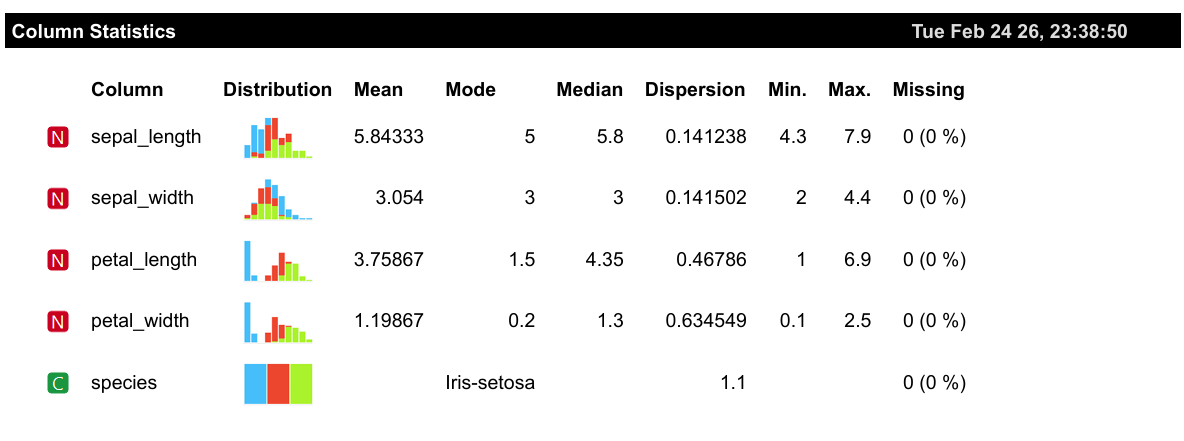

### **Visualisasi Bar Chart**

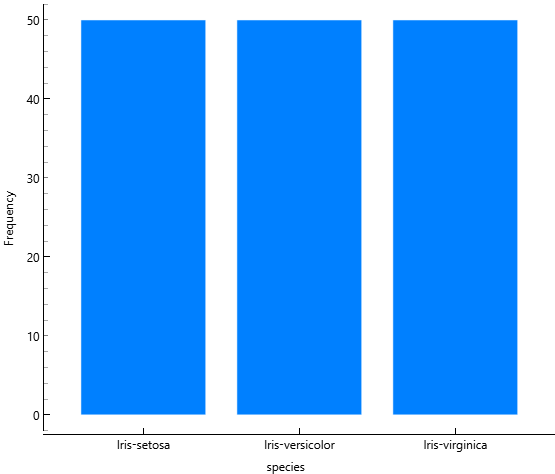

### **Pivot Table**

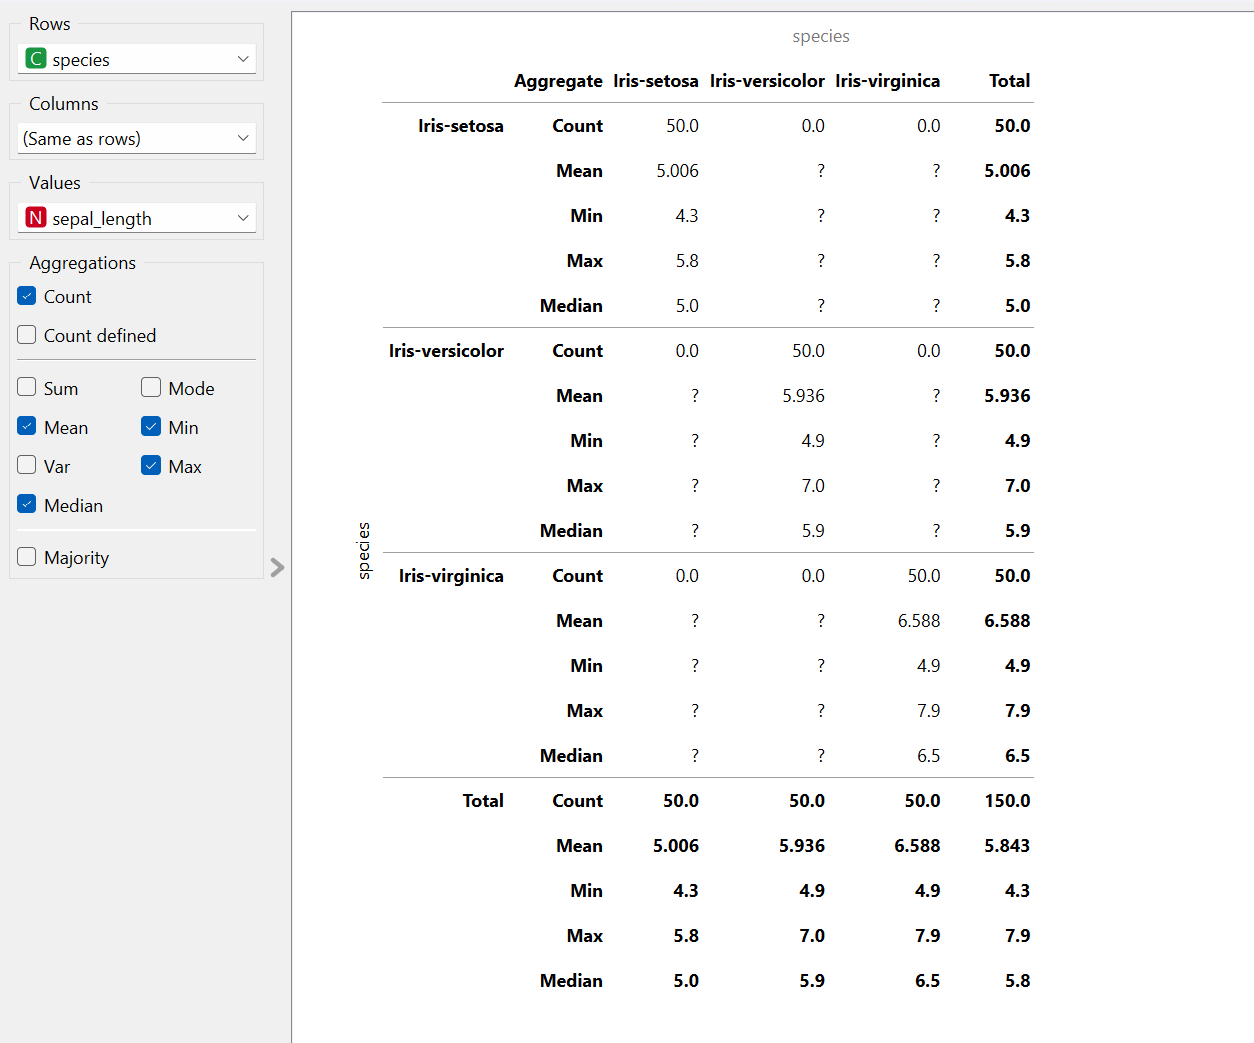

### **Analisa Korelasi pada orange**

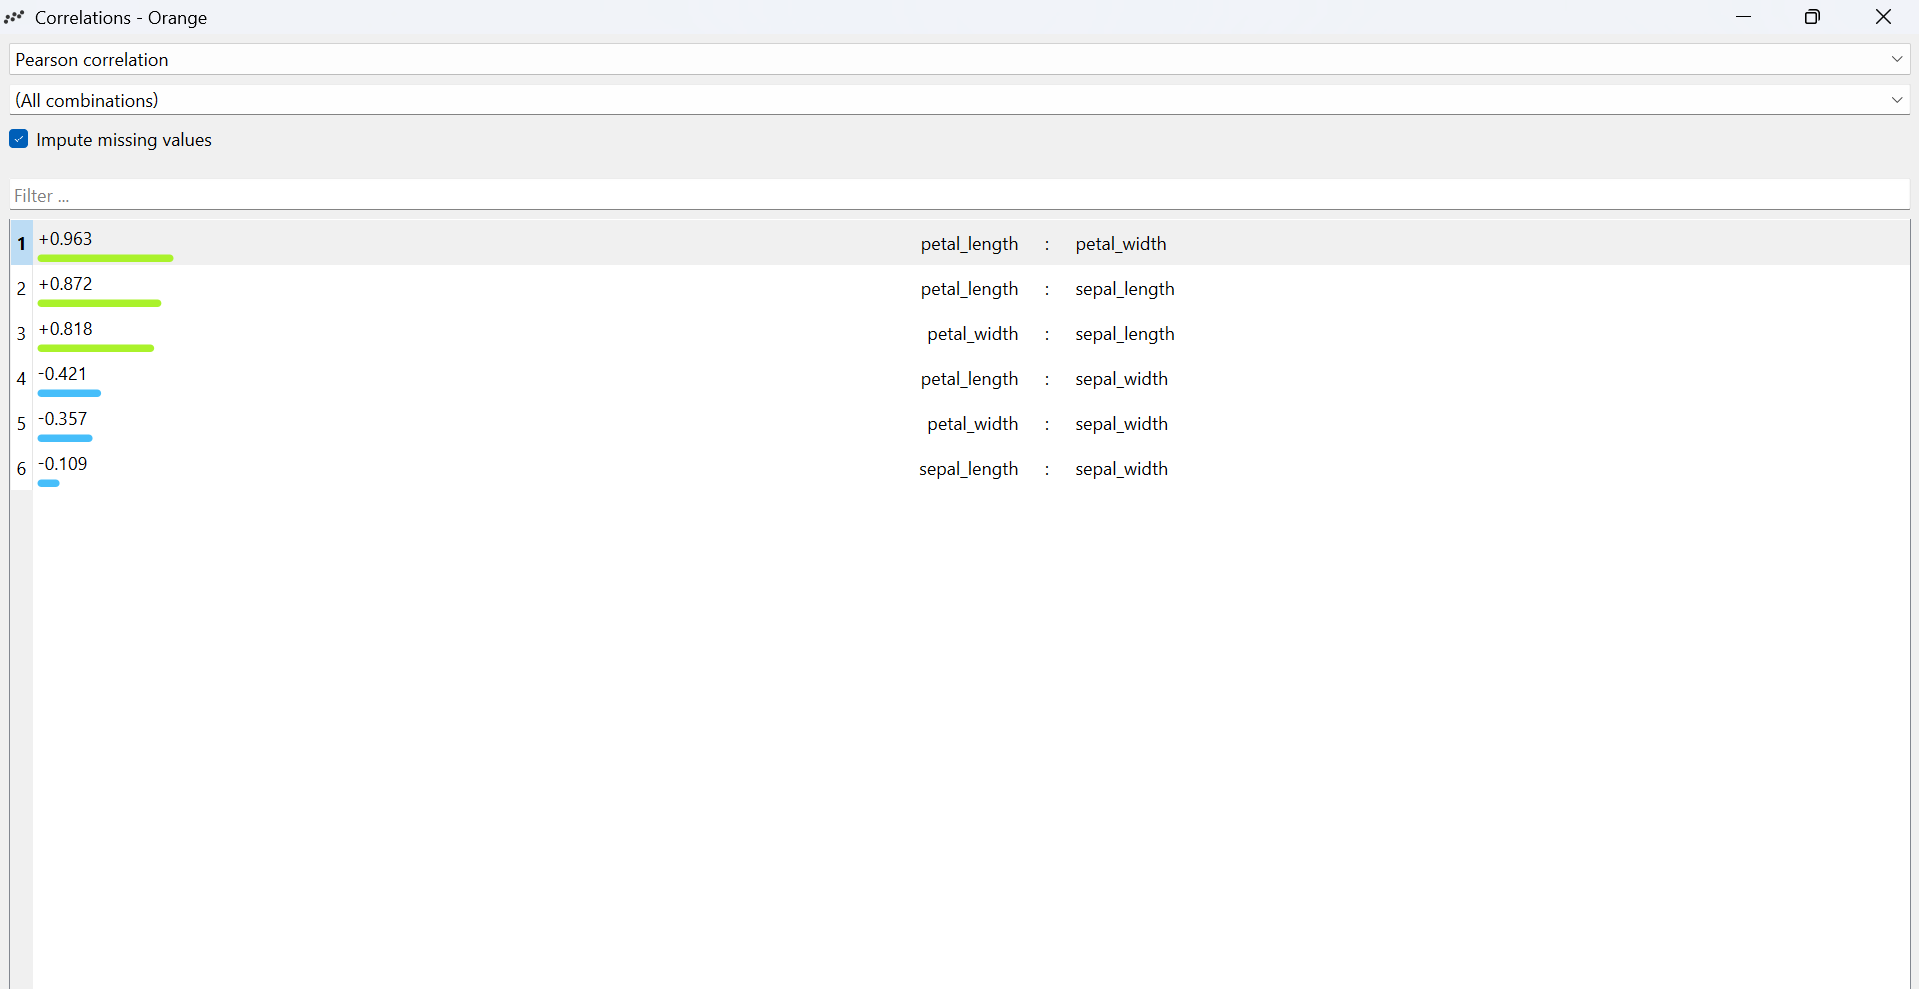

#6. Mengukur jarak data

##6.1 Pengertian Similarity dan Dissimilarity

###6.1.1 Similarity

Namanya saja similarity, jadi yang diukur adalah tingkat kemiripan antara dua objek yang dibandingkan. Semakin besar nilai yang diperoleh, maka semakin mirip kedua objek tersebut. Nilai similarity berada pada rentang [0,1], di mana nilai yang lebih tinggi menunjukkan tingkat kemiripan yang semakin besar antara objek yang dimaksud.

###6.1.2 Dissimilarity

Kebalikan dari similarity, dissimilarity digunakan untuk mengukur tingkat perbedaan antara dua objek yang dibandingkan. Nilainya dimulai dari 0, dan semakin besar nilai yang diperoleh, maka semakin berbeda atau semakin tidak mirip kedua objek tersebut. Contoh dissimilarity:

####6.1.2.1 Minkowski Distance

Minkowski Distance adalah bentuk generalisasi dari Euclidean dan Manhattan.
Artinya Euclidean dan Manhattan merupakan bagian dari kelompok Minkowski Distance.

$$
d(i,j) =
\sqrt[h]{|x_{i1} - x_{j1}|^h + |x_{i2} - x_{j2}|^h + \cdots + |x_{ip} - x_{jp}|^h}
$$

dengan:

$$
i = (x_{i1}, x_{i2}, ..., x_{ip})
$$

$$
j = (x_{j1}, x_{j2}, ..., x_{jp})
$$

Keterangan:

- **i** : Melambangkan objek ke-i  
- **j** : Melambangkan objek ke-j  
- **xᵢ₁** : Nilai fitur ke-1 dari objek ke-i  
- **xⱼ₁** : Nilai fitur ke-1 dari objek ke-j  
- **p** : Jumlah total fitur atau atribut pada data  
- **h** : Parameter Minkowski yang menentukan jenis jarak  

Jika nilai **h = 1**, maka rumus tersebut menjadi **Manhattan Distance**.  
Jika nilai **h = 2**, maka rumus tersebut menjadi **Euclidean Distance**.

####6.1.2.2 Manhattan Distance

Manhattan Distance digunakan untuk menghitung jarak antara dua titik dengan cara menjumlahkan nilai selisih absolut dari setiap koordinatnya. Metode ini lebih tahan terhadap pengaruh outlier dibandingkan Euclidean Distance, sehingga sering digunakan pada data dengan dimensi yang cukup tinggi.

$$
d(i,j) = |x_{i1} - x_{j1}| + |x_{i2} - x_{j2}| + \cdots + |x_{ip} - x_{jp}|
$$

####6.1.2.3 Euclidean Distance

Euclidean Distance merupakan metode pengukuran jarak yang umum digunakan pada data bertipe numerik, terutama dalam proses pengelompokan data. Namun, salah satu kelemahan dari metode ini adalah fitur dengan skala paling besar dapat memberikan pengaruh yang lebih dominan terhadap hasil perhitungan jarak. Oleh karena itu, normalisasi pada fitur kontinu sering dilakukan untuk mengurangi masalah tersebut.

$$
d(i,j) = \sqrt{(x_{i1}-x_{j1})^2 + (x_{i2}-x_{j2})^2 + \cdots + (x_{ip}-x_{jp})^2}
$$

##6.2 Mengukur jarak dissimilarity pada suatu dataset

###6.2.1 Mengukur jarak dataset Iris

Pada dataset Iris yang digunakan, seluruh atribut memiliki tipe data numerik. Oleh karena itu, metode perhitungan jarak yang dipakai pada data Iris tersebut adalah Euclidean Distance.

####6.2.1.1 Perhitungan manual

Contoh perhitungan jarak secara manual antara data pada baris ke-2 dan baris ke-1:

$$
d(2,1) = \sqrt{(|4.9 - 5.1|^2 + |3 - 3.5|^2 + |1.4 - 1.4|^2 + |0.2 - 0.2|^2)}
$$

$$
= \sqrt{0.04 + 0.25}
$$

$$
= 0.538
$$

Perhitungan berikutnya dilakukan antara data pada baris ke-3 dan baris ke-1:

$$
d(3,1) = \sqrt{(|4.7 - 5.1|^2 + |3.2 - 3.5|^2 + |1.3 - 1.4|^2 + |0.2 - 0.2|^2)}
$$

$$
= \sqrt{0.16 + 0.09 + 0.01 + 0}
$$

$$
= 0.50990
$$

####6.2.1.2 Perhitungan Python

Kita juga dapat menggunakan tools seperti python untuk mempermudah perhitungan ini



In [ ]:
from scipy.spatial.distance import pdist, squareform

X = df.select_dtypes(include=['float64', 'int64'])
dist = pdist(X, metric='euclidean')
distance_matrix = squareform(dist)

distance_df = pd.DataFrame(distance_matrix)
print(distance_df.iloc[:5, :5])

Terdapat library tambahan yang digunakan, yaitu scipy, yang berfungsi untuk mempermudah proses perhitungan Euclidean Distance tanpa harus menuliskan perhitungan tersebut secara manual dalam kode. Setelah itu, data yang ditampilkan dibatasi hanya sebanyak 5×5, dimulai dari data pertama.

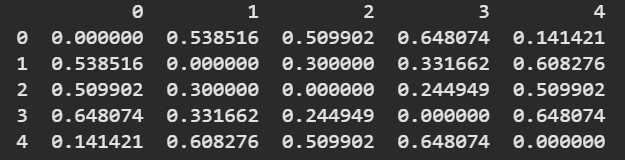

####6.2.1.3 Perhitungan Orange

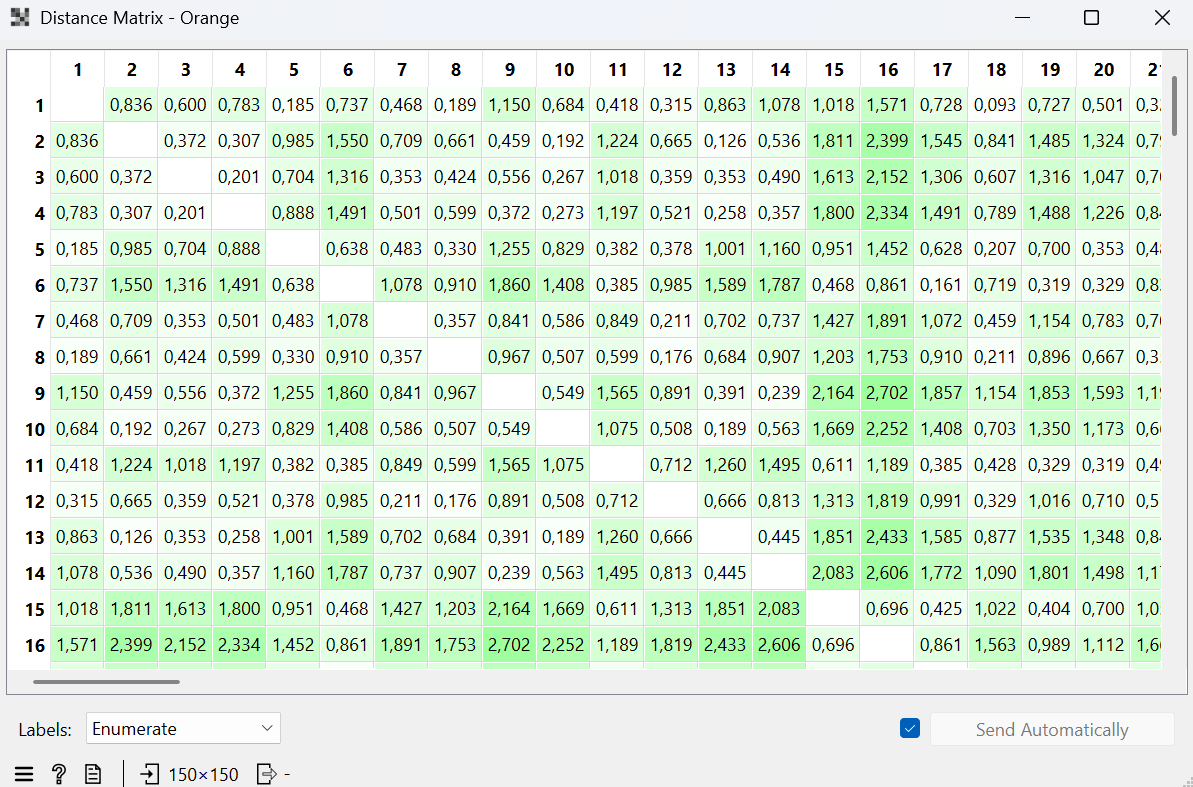

3 perhitungan diatas, memiliki kesamaan nilai, artinya perhitungan yang dilakukan sudah dilakukan secara benar dan urut

###6.2.2 Mengukur jarak dataset Tipe data campuran

Dataset yang digunakan untuk contoh kali ini adalah dataset berjudu; ‘Student Alcohol Consumption’. Dimana dataset ini memiliki sekitar 30 fitur di dalam nya. Namun pada penugasan kali ini, kami menggunakan hanya 7 fitur diantaranya yaitu fitur sex, age, Medu, Fedu, Fjob, activities, schoolsup. Dimana tipe data Nominal dimiliki oleh [sex, fjob, activities, schoolsup] lalu tipe data numerik [Age] terakhir adalah tipe data ordinal [medu, fedu]. Dilakukan perhitungan jarak dengan metode Gower Dataset Student alcohol consumption



####6.2.2.1 Perhitungan manual

Contoh perhitungan manual antara baris 1 dan 2, lalu baris 1 dan 4:



#####1. Hitung Nominal pada baris 1 dan 2

Jika nilai nya sama -> 0 Jika nilai nya beda -> 1



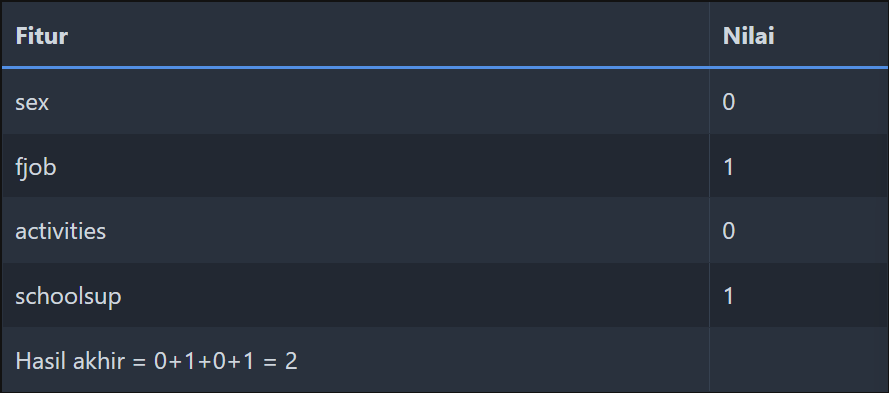

#####2. Hitung Numerik pada baris 1 dan 2

Pada fitur **Age**, data yang digunakan bertipe numerik dengan nilai minimum sebesar **15** dan nilai maksimum sebesar **22**. Perhitungan jarak untuk atribut numerik dapat dilakukan menggunakan rumus berikut:

$$
d_{ij}^{(f)} = \frac{|x_{if} - x_{jf}|}{\max(x_f) - \min(x_f)}
$$

Contoh perhitungan antara data ke-1 dan data ke-2:

$$
d_{1,2}^{(f)} = \frac{|18 - 17|}{22 - 15}
$$

$$
= \frac{1}{7} = 0.143
$$

Sehingga nilai jarak yang diperoleh adalah **0.143**.

#####3. Hitung Ordinal pada baris 1 dan 2

Langkah pertama adalah menentukan jumlah kategori yang terdapat pada atribut tersebut. Pada kasus ini diketahui terdapat **5 kategori**. Proses normalisasi dapat dihitung menggunakan rumus berikut:

$$
z_{if} = \frac{r_{if} - \min(r_f)}{\max(r_f) - \min(r_f)}
$$

Perhitungan untuk data pada baris ke-1:

$$
z_1 = \frac{4 - 0}{4 - 0}
$$

$$
= \frac{4}{4} = 1
$$

Perhitungan untuk data pada baris ke-2:

$$
z_1 = \frac{1 - 0}{4 - 0}
$$

$$
= \frac{1}{4} = 0.25
$$

Nilai jarak yang diperoleh:

$$
|1 - 0.25| = 0.75
$$

Langkah perhitungan yang sama dapat diterapkan pada atribut **fedu**, sehingga diperoleh hasil akhir sebesar **0.75**.

#####3. Hasil Akhir nilai gower baris 1 dan 2

Nilai yang diperoleh dari setiap tipe data sebelumnya kemudian dijumlahkan. Setelah itu, total nilai tersebut dibagi dengan jumlah fitur yang digunakan untuk mendapatkan nilai akhirnya.

$$
= \frac{2 + 0.143 + 0.75 + 0.75}{7}
$$

$$
= 0.520
$$

####6.2.2.2 Perhitungan Python

In [ ]:
import numpy as np

data = df.copy()
n = data.shape[0]

numeric_cols = data.select_dtypes(include=[np.number]).columns
categorical_cols = data.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols:
   min_val = data[col].min()
   max_val = data[col].max()

   if max_val != min_val:
       data[col] = (data[col] - min_val) / (max_val - min_val)
   else:
       data[col] = 0

dist_matrix = np.zeros((n, n))

for i in range(n):
   for j in range(n):
       total_dist = 0
       valid_features = 0

       for col in data.columns:
           xi = data.iloc[i][col]
           xj = data.iloc[j][col]

           if pd.isna(xi) or pd.isna(xj):
               continue

           if col in numeric_cols:
               d = abs(xi - xj)

           else:
               d = 0 if xi == xj else 1

           total_dist += d
           valid_features += 1

       dist_matrix[i, j] = total_dist / valid_features
distance_df = pd.DataFrame(dist_matrix)

print(distance_df.iloc[:5, :5])

Berikut adalah code yang digunakan untuk menghitung gower distance

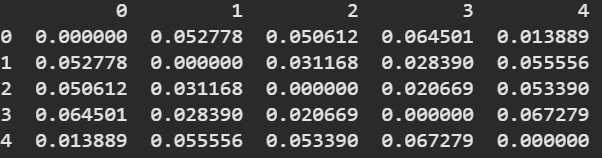